# DBSCAN and Hierarchical Clustering Across Healthcare Datasets

This notebook applies unsupervised clustering methods across multiple healthcare-related datasets, including diabetes, life expectancy, and SUPPORT2. The workflow compares density-based clustering with DBSCAN and hierarchical agglomerative clustering (HAC), including baseline models, parameter tuning, linkage-method comparisons, silhouette-score evaluation, cluster-size review, and dendrogram visualization.

This notebook is included in the modeling folder because the main focus is unsupervised model development, clustering evaluation, and comparison of clustering behavior across datasets rather than exploratory data analysis.


## Diabetes Dataset Clustering

This section applies DBSCAN and hierarchical agglomerative clustering to the diabetes dataset. The goal is to examine whether health-indicator patterns form meaningful clusters and to compare density-based clustering with hierarchical clustering.


In [14]:
#Diabetes imputed

import pandas as pd

diabetes = pd.read_csv("diabetes_no_duplicates.csv")
print(diabetes.shape)
diabetes.head()

(229781, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


### DBSCAN Clustering for Diabetes

DBSCAN is tested using baseline parameters and a small tuning grid for `eps` and `min_samples`. The results are evaluated using the number of clusters, percentage of noise points, and silhouette score.


In [15]:
#Baseline DBSCAN on the Diabetes data

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

#all features except the target for clustering
X = diabetes.drop(columns=['Diabetes_012'])

#all features on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Baseline DBSCAN model (first simple try)
# eps = radius for neighbors
# min_samples = how many points needed to form a dense region
dbscan_base = DBSCAN(
    eps=1.5,
    min_samples=50,
    metric='euclidean',
    n_jobs=-1
)

base_labels = dbscan_base.fit_predict(X_scaled)

#cluster labels (including noise points) back to the dataframe
diabetes['DBSCAN_cluster_base'] = base_labels

# How many points in each cluster (including noise = -1)?
unique, counts = np.unique(base_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
print("Baseline cluster label -> count:", cluster_counts)
print("Note: label -1 = 'noise' points that DBSCAN could not assign to a cluster.")

#Silhouette scores on samples 
max_samples = 10000  

#Silhouette score on NON-noise points (common way to evaluate DBSCAN)
mask_non_noise = base_labels != -1
idx_non_noise = np.where(mask_non_noise)[0]

if len(idx_non_noise) > 1 and len(set(base_labels[mask_non_noise])) > 1:
    # take at most max_samples points
    if len(idx_non_noise) > max_samples:
        idx_non_noise = np.random.choice(idx_non_noise, size=max_samples, replace=False)
    X_sub = X_scaled[idx_non_noise]
    labels_sub = base_labels[idx_non_noise]
    sil_base = silhouette_score(X_sub, labels_sub)
    print(f"Baseline silhouette score (excluding noise, sample size = {len(idx_non_noise)}):", sil_base)
else:
    print("Not enough non-noise clusters to compute a silhouette score (excluding noise).")

#Silhouette score including noise as its own cluster (also on a sample)
idx_all = np.arange(len(base_labels))
if len(set(base_labels)) > 1:
    if len(idx_all) > max_samples:
        idx_all = np.random.choice(idx_all, size=max_samples, replace=False)
    X_sub_all = X_scaled[idx_all]
    labels_sub_all = base_labels[idx_all]
    sil_with_noise = silhouette_score(X_sub_all, labels_sub_all)
    print(f"Baseline silhouette score (including noise, sample size = {len(idx_all)}):", sil_with_noise)
else:
    print("Not enough clusters (including noise) to compute a silhouette score.")

Baseline cluster label -> count: {np.int64(-1): np.int64(101663), np.int64(0): np.int64(3767), np.int64(1): np.int64(3870), np.int64(2): np.int64(2407), np.int64(3): np.int64(3708), np.int64(4): np.int64(312), np.int64(5): np.int64(730), np.int64(6): np.int64(10941), np.int64(7): np.int64(1775), np.int64(8): np.int64(975), np.int64(9): np.int64(305), np.int64(10): np.int64(3480), np.int64(11): np.int64(2829), np.int64(12): np.int64(2405), np.int64(13): np.int64(385), np.int64(14): np.int64(1934), np.int64(15): np.int64(1395), np.int64(16): np.int64(1160), np.int64(17): np.int64(299), np.int64(18): np.int64(1113), np.int64(19): np.int64(216), np.int64(20): np.int64(5145), np.int64(21): np.int64(688), np.int64(22): np.int64(2447), np.int64(23): np.int64(1059), np.int64(24): np.int64(530), np.int64(25): np.int64(2290), np.int64(26): np.int64(333), np.int64(27): np.int64(519), np.int64(28): np.int64(1218), np.int64(29): np.int64(1239), np.int64(30): np.int64(1932), np.int64(31): np.int64(2

In [17]:
#Simple DBSCAN hyperparameter tuning

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

#already have X_scaled above

eps_values = [1.2, 1.5]      
min_samples_values = [30, 50]  

max_samples = 8000
results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples,
                    metric='euclidean', n_jobs=-1)
        labels = db.fit_predict(X_scaled)

        # number of clusters
        unique, counts = np.unique(labels, return_counts=True)
        cluster_counts = dict(zip(unique, counts))
        num_clusters = len([c for c in cluster_counts if c != -1])

        # percent of noise points
        noise_pct = cluster_counts.get(-1, 0) / len(labels)

        sil = np.nan
        mask = labels != -1
        if mask.sum() > 1 and num_clusters > 1:
            idx = np.where(mask)[0]
            if len(idx) > max_samples:
                idx = np.random.choice(idx, size=max_samples, replace=False)
            X_sub = X_scaled[idx]
            labels_sub = labels[idx]
            sil = silhouette_score(X_sub, labels_sub)

        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "num_clusters": num_clusters,
            "noise_pct": noise_pct,
            "silhouette": sil
        })

results_df = pd.DataFrame(results)
print(results_df)

   eps  min_samples  num_clusters  noise_pct  silhouette
0  1.2           30           171   0.512479    0.226986
1  1.2           50           117   0.577215    0.231348
2  1.5           30           263   0.392287    0.202625
3  1.5           50           182   0.442434    0.209264


In [18]:
#Final DBSCAN model using best tuned parameters

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

#Pick the row with the best silhouette
best_row = results_df.sort_values(by="silhouette", ascending=False).iloc[0]
best_eps = float(best_row["eps"])
best_min_samples = int(best_row["min_samples"])
print("Best parameters from tuning:", best_row)

#Fit final DBSCAN with these parameters
dbscan_final = DBSCAN(eps=best_eps,
                      min_samples=best_min_samples,
                      metric='euclidean',
                      n_jobs=-1)

final_labels = dbscan_final.fit_predict(X_scaled)
diabetes["DBSCAN_cluster_final"] = final_labels

#Quick summary of the final model
unique, counts = np.unique(final_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
num_clusters = len([c for c in cluster_counts if c != -1])
noise_pct = cluster_counts.get(-1, 0) / len(final_labels)

print("\nFinal model summary:")
print("Number of clusters (excluding noise):", num_clusters)
print("Percent noise points (-1):", round(noise_pct * 100, 1), "%")

#Silhouette on a sample for the final model
mask = final_labels != -1
idx = np.where(mask)[0]
max_samples = 8000
if mask.sum() > 1 and num_clusters > 1:
    if len(idx) > max_samples:
        idx = np.random.choice(idx, size=max_samples, replace=False)
    X_sub = X_scaled[idx]
    labels_sub = final_labels[idx]
    sil_final = silhouette_score(X_sub, labels_sub)
    print("Final silhouette score (sample, excluding noise):", sil_final)
else:
    print("Not enough non-noise points for a silhouette score.")

Best parameters from tuning: eps               1.200000
min_samples      50.000000
num_clusters    117.000000
noise_pct         0.577215
silhouette        0.231348
Name: 1, dtype: float64

Final model summary:
Number of clusters (excluding noise): 117
Percent noise points (-1): 57.7 %
Final silhouette score (sample, excluding noise): 0.2316445763252316


### Hierarchical Agglomerative Clustering for Diabetes

Hierarchical clustering is applied to a sample of the diabetes dataset to keep the computation manageable. Ward, complete, and average linkage methods are compared using silhouette score, and a dendrogram is used to visualize the clustering structure.


In [19]:
# Baseline Hierarchical Agglomerative Clustering (HAC)

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

#keep HAC manageable, random sample
sample_size = 10000
rng = np.random.RandomState(42)
idx_hac = rng.choice(X_scaled.shape[0], size=sample_size, replace=False)
X_hac = X_scaled[idx_hac]

#Baseline HAC with Ward linkage and 4 clusters (pick 3–5)
hac_ward = AgglomerativeClustering(n_clusters=4, linkage='ward')
hac_labels_ward = hac_ward.fit_predict(X_hac)

sil_ward = silhouette_score(X_hac, hac_labels_ward)
print("Baseline HAC (ward) silhouette:", sil_ward)

Baseline HAC (ward) silhouette: 0.14570366402888063


In [20]:
#linkage methods in HAC

linkages = ['ward', 'complete', 'average']
results_hac = []

for link in linkages:
    hac = AgglomerativeClustering(n_clusters=4, linkage=link)
    labels = hac.fit_predict(X_hac)
    sil = silhouette_score(X_hac, labels)
    results_hac.append({"linkage": link, "silhouette": sil})

results_hac

[{'linkage': 'ward', 'silhouette': np.float64(0.14570366402888063)},
 {'linkage': 'complete', 'silhouette': np.float64(0.2219360207995124)},
 {'linkage': 'average', 'silhouette': np.float64(0.3313837278270036)}]

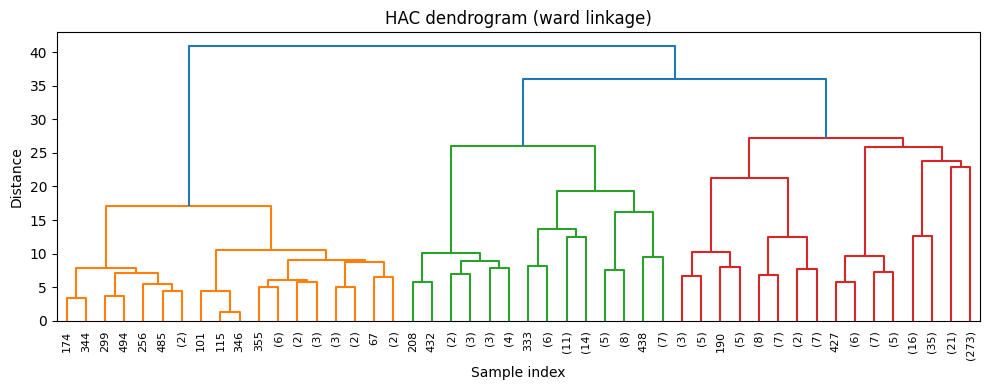

In [23]:
#Dendrogram for HAC

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Use a smaller sample just for plotting, so the dendrogram is readable
idx_dendro = rng.choice(X_scaled.shape[0], size=500, replace=False)
X_dendro = X_scaled[idx_dendro]

Z = linkage(X_dendro, method='ward')  # or best linkage

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode='level', p=5)  # show top levels
plt.title("HAC dendrogram (ward linkage)")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Diabetes Clustering Summary

The diabetes results show that DBSCAN identifies many small clusters and a high percentage of noise points, suggesting that the data may not separate cleanly into dense groups. HAC provides an additional comparison of linkage methods and a visual hierarchy through the dendrogram.


## Life Expectancy Dataset Clustering

This section applies DBSCAN and hierarchical agglomerative clustering to the life expectancy dataset using scaled numeric features. The goal is to compare how density-based and hierarchical clustering methods group country-level health and development indicators.


In [27]:
#Life Expectancy imputed

import pandas as pd

life_imputed = pd.read_csv("Life Expectancy Data - mean_mode_imputed.csv")

print(life_imputed.shape)
life_imputed.head()

(2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [28]:
import numpy as np
from sklearn.preprocessing import StandardScaler

#only numeric columns for clustering
life_num = life_imputed.select_dtypes(include=[np.number])

print(life_num.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(life_num)

(2938, 20)


### DBSCAN Clustering for Life Expectancy

DBSCAN is evaluated with baseline parameters and a tuning grid for `eps` and `min_samples`. The clustering results are compared using noise percentage, number of clusters, and silhouette score.


In [29]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Baseline DBSCAN model
dbscan_base = DBSCAN(
    eps=1.5,
    min_samples=10,
    metric='euclidean',
    n_jobs=-1
)

base_labels = dbscan_base.fit_predict(X_scaled)
life_imputed["DBSCAN_base"] = base_labels

# Metrics
unique, counts = np.unique(base_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
num_clusters_base = len([c for c in cluster_counts if c != -1])
noise_pct_base = cluster_counts.get(-1, 0) / len(base_labels)

print("Baseline DBSCAN cluster counts:", cluster_counts)
print("Baseline #clusters (excluding noise):", num_clusters_base)
print("Baseline % noise (-1):", round(noise_pct_base * 100, 1), "%")

mask = base_labels != -1
if mask.sum() > 1 and num_clusters_base > 1:
    sil_base = silhouette_score(X_scaled[mask], base_labels[mask])
    print("Baseline silhouette (excluding noise):", sil_base)
else:
    print("Baseline: not enough non-noise clusters for silhouette.")

Baseline DBSCAN cluster counts: {np.int64(-1): np.int64(1316), np.int64(0): np.int64(10), np.int64(1): np.int64(1468), np.int64(2): np.int64(14), np.int64(3): np.int64(53), np.int64(4): np.int64(15), np.int64(5): np.int64(11), np.int64(6): np.int64(20), np.int64(7): np.int64(10), np.int64(8): np.int64(10), np.int64(9): np.int64(11)}
Baseline #clusters (excluding noise): 10
Baseline % noise (-1): 44.8 %
Baseline silhouette (excluding noise): -0.030405030515771404


In [31]:
eps_values = [0.8, 1.0, 1.2, 1.5, 1.6]
min_samples_values = [5, 10, 20]

results_db = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric='euclidean',
            n_jobs=-1
        )
        labels = db.fit_predict(X_scaled)

        unique, counts = np.unique(labels, return_counts=True)
        cluster_counts = dict(zip(unique, counts))
        num_clusters = len([c for c in cluster_counts if c != -1])
        noise_pct = cluster_counts.get(-1, 0) / len(labels)

        sil = np.nan
        mask = labels != -1
        if mask.sum() > 1 and num_clusters > 1:
            sil = silhouette_score(X_scaled[mask], labels[mask])

        results_db.append({
            "eps": eps,
            "min_samples": min_samples,
            "num_clusters": num_clusters,
            "noise_pct": noise_pct,
            "silhouette": sil
        })

results_db_df = pd.DataFrame(results_db)
print(results_db_df)

    eps  min_samples  num_clusters  noise_pct  silhouette
0   0.8            5            56   0.845133    0.421267
1   0.8           10             1   0.990129         NaN
2   0.8           20             0   1.000000         NaN
3   1.0            5            56   0.615385    0.053517
4   1.0           10             8   0.876447    0.169403
5   1.0           20             1   0.981280         NaN
6   1.2            5            44   0.462900   -0.116854
7   1.2           10            12   0.646358    0.003369
8   1.2           20             2   0.826072    0.175283
9   1.5            5            37   0.325391   -0.134165
10  1.5           10            10   0.447924   -0.030405
11  1.5           20             3   0.543567    0.276004
12  1.6            5            37   0.289993   -0.064084
13  1.6           10             9   0.404016    0.035935
14  1.6           20             2   0.488768    0.272302


In [32]:
# Final DBSCAN model using best tuned parameters

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

#Pick the best row (highest silhouette among reasonable combos)
valid_db = results_db_df.dropna()
valid_db = valid_db[(valid_db["num_clusters"] >= 2) & (valid_db["noise_pct"] < 0.8)]

best_db_row = valid_db.sort_values("silhouette", ascending=False).iloc[0]
best_eps = float(best_db_row["eps"])
best_min_samples = int(best_db_row["min_samples"])

print("Best DBSCAN params from tuning:")
print(best_db_row)

# Fit final DBSCAN with these parameters
dbscan_final = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric='euclidean',
    n_jobs=-1
)

final_db_labels = dbscan_final.fit_predict(X_scaled)
life_imputed["DBSCAN_final"] = final_db_labels

# Summary of the final model
unique, counts = np.unique(final_db_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
num_clusters_final = len([c for c in cluster_counts if c != -1])
noise_pct_final = cluster_counts.get(-1, 0) / len(final_db_labels)

print("\nFinal DBSCAN summary:")
print("Cluster counts:", cluster_counts)
print("#clusters (excluding noise):", num_clusters_final)
print("% noise (-1):", round(noise_pct_final * 100, 1), "%")

# Silhouette for the final model (excluding noise)
mask = final_db_labels != -1
if mask.sum() > 1 and num_clusters_final > 1:
    sil_final = silhouette_score(X_scaled[mask], final_db_labels[mask])
    print("Final silhouette (excluding noise):", sil_final)
else:
    print("Not enough non-noise points for a silhouette score.")

Best DBSCAN params from tuning:
eps              1.500000
min_samples     20.000000
num_clusters     3.000000
noise_pct        0.543567
silhouette       0.276004
Name: 11, dtype: float64

Final DBSCAN summary:
Cluster counts: {np.int64(-1): np.int64(1597), np.int64(0): np.int64(1300), np.int64(1): np.int64(21), np.int64(2): np.int64(20)}
#clusters (excluding noise): 3
% noise (-1): 54.4 %
Final silhouette (excluding noise): 0.27600438249858916


### Hierarchical Agglomerative Clustering for Life Expectancy

Hierarchical clustering is evaluated using multiple linkage methods and cluster counts. A dendrogram is included to show how observations merge across the hierarchical clustering process.


In [33]:
# Baseline Hierarchical Agglomerative Clustering (HAC) on Life Expectancy

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

# X_scaled: scaled numeric features from life_imputed

# Baseline HAC: Ward linkage, 4 clusters (4 is a common start)
hac_ward = AgglomerativeClustering(n_clusters=4, linkage='ward')
hac_labels_ward = hac_ward.fit_predict(X_scaled)

# Save labels back to the dataframe
life_imputed["HAC_ward_4"] = hac_labels_ward

# Cluster sizes
unique, counts = np.unique(hac_labels_ward, return_counts=True)
cluster_sizes = dict(zip(unique, counts))
print("Baseline HAC (ward, 4 clusters) sizes:", cluster_sizes)

# Silhouette on the full dataset
sil_ward = silhouette_score(X_scaled, hac_labels_ward)
print("Baseline HAC (ward) silhouette:", sil_ward)

Baseline HAC (ward, 4 clusters) sizes: {np.int64(0): np.int64(1216), np.int64(1): np.int64(1427), np.int64(2): np.int64(16), np.int64(3): np.int64(279)}
Baseline HAC (ward) silhouette: 0.19659386956013655


In [34]:
#Linkage methods in HAC + tuning

linkages = ['ward', 'complete', 'average']
k_values = [3, 4, 5, 6]   # numbers of clusters to try

hac_results = []

for link in linkages:
    for k in k_values:
        hac = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = hac.fit_predict(X_scaled)

        #metrics: silhouette + cluster sizes
        sil = silhouette_score(X_scaled, labels)
        unique, counts = np.unique(labels, return_counts=True)
        cluster_sizes = dict(zip(unique, counts))

        hac_results.append({
            "linkage": link,
            "n_clusters": k,
            "silhouette": sil,
            "cluster_sizes": cluster_sizes
        })

import pandas as pd
hac_results_df = pd.DataFrame(hac_results)
print(hac_results_df)

     linkage  n_clusters  silhouette  \
0       ward           3    0.233155   
1       ward           4    0.196594   
2       ward           5    0.202728   
3       ward           6    0.189200   
4   complete           3    0.668423   
5   complete           4    0.619895   
6   complete           5    0.536652   
7   complete           6    0.367284   
8    average           3    0.706038   
9    average           4    0.555925   
10   average           5    0.476531   
11   average           6    0.429913   

                                      cluster_sizes  
0                         {0: 1706, 1: 1216, 2: 16}  
1                 {0: 1216, 1: 1427, 2: 16, 3: 279}  
2          {0: 1128, 1: 1427, 2: 16, 3: 279, 4: 88}  
3   {0: 490, 1: 1427, 2: 16, 3: 279, 4: 88, 5: 638}  
4                            {0: 22, 1: 5, 2: 2911}  
5                     {0: 2911, 1: 11, 2: 11, 3: 5}  
6              {0: 2899, 1: 11, 2: 11, 3: 5, 4: 12}  
7       {0: 94, 1: 11, 2: 2805, 3: 5, 4: 12, 5:

In [35]:
#best HAC setting by silhouette
best_hac_row = hac_results_df.sort_values("silhouette", ascending=False).iloc[0]
best_linkage = best_hac_row["linkage"]
best_k = int(best_hac_row["n_clusters"])

print("\nBest HAC params from tuning:")
print(best_hac_row)


Best HAC params from tuning:
linkage                         average
n_clusters                            3
silhouette                     0.706038
cluster_sizes    {0: 2922, 1: 5, 2: 11}
Name: 8, dtype: object


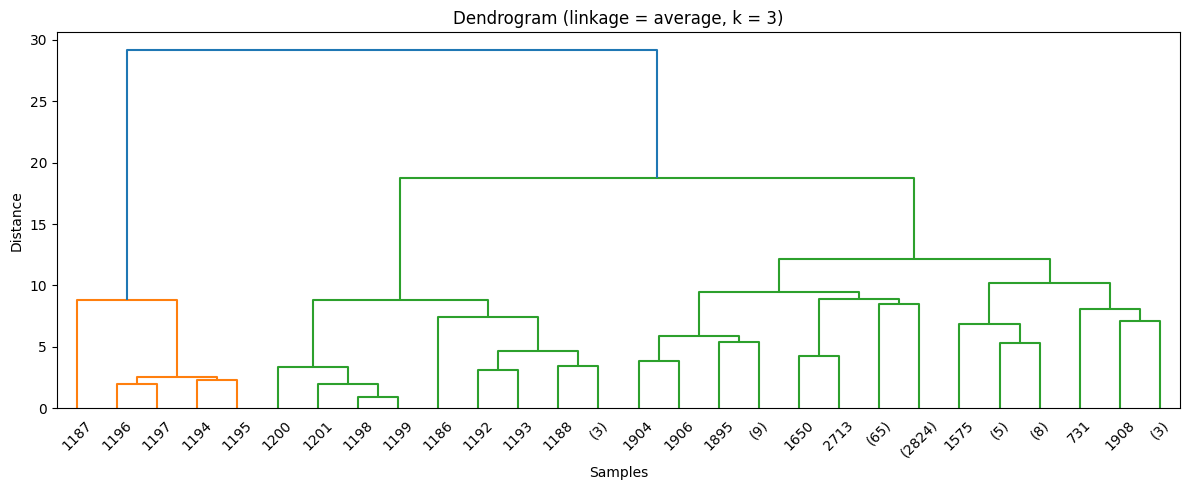

In [36]:
#Dendrogram for HAC

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

#best linkage from tuning
Z = linkage(X_scaled, method=best_linkage)

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='level', p=5)  # show top levels so it's readable
plt.title(f"Dendrogram (linkage = {best_linkage}, k = {best_k})")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Life Expectancy Clustering Summary

The life expectancy results show that clustering structure varies strongly by method and linkage choice. DBSCAN separates part of the dataset into clusters with some noise, while HAC linkage comparisons highlight how hierarchical methods can produce very different cluster patterns.


## SUPPORT2 Dataset Clustering

This section applies DBSCAN and hierarchical agglomerative clustering to the SUPPORT2 clinical dataset using scaled numeric features. The goal is to evaluate whether patient-level clinical variables form useful clusters under density-based and hierarchical methods.


In [38]:
#Support2 imputed
import pandas as pd

support2_imputed = pd.read_csv("support2_imputed.csv")

print(support2_imputed.shape)
support2_imputed.head()

(9105, 45)


,age,sex,dzgroup,dzclass,num.co,edu,income,scoma,charges,totcst,...,ph,glucose,bun,urine,adlp,adls,adlsc,death,hospdead,sfdm2
0,62.84998,male,Lung Cancer,Cancer,0,11.000000,$11-$25k,0.0,9715.0,30825.867768,...,7.459961,159.873398,32.349463,2191.546047,7.00000,7.0,7.0,0,0,<2 mo. follow-up
1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,$11-$25k,44.0,34496.0,30825.867768,...,7.250000,159.873398,32.349463,2191.546047,1.15791,1.0,1.0,1,1,<2 mo. follow-up
2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,12.000000,under $11k,0.0,41094.0,30825.867768,...,7.459961,159.873398,32.349463,2191.546047,1.00000,0.0,0.0,1,0,<2 mo. follow-up
3,42.38498,female,Lung Cancer,Cancer,2,11.000000,under $11k,0.0,3075.0,30825.867768,...,7.415364,159.873398,32.349463,2191.546047,0.00000,0.0,0.0,1,0,no(M2 and SIP pres)
4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,11.747691,under $11k,26.0,50127.0,30825.867768,...,7.509766,159.873398,32.349463,2191.546047,1.15791,2.0,2.0,0,0,no(M2 and SIP pres)


In [39]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Use only numeric columns for clustering
support2_num = support2_imputed.select_dtypes(include=[np.number])
print(support2_num.shape)

scaler = StandardScaler()
X_scaled_s2 = scaler.fit_transform(support2_num)

(9105, 37)


### DBSCAN Clustering for SUPPORT2

DBSCAN is first tested with baseline parameters, then tuned with larger `eps` values and smaller `min_samples` values because the SUPPORT2 data initially produced mostly noise. The final DBSCAN model is selected based on reasonable cluster formation and silhouette score.


In [40]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Baseline DBSCAN settings (first try)
dbscan_s2_base = DBSCAN(
    eps=1.5,
    min_samples=10,
    metric='euclidean',
    n_jobs=-1
)

s2_base_labels = dbscan_s2_base.fit_predict(X_scaled_s2)
support2_imputed["DBSCAN_base"] = s2_base_labels

# Metrics: cluster counts, #clusters, % noise
unique, counts = np.unique(s2_base_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))

num_clusters_base = len([c for c in cluster_counts if c != -1])
noise_pct_base = cluster_counts.get(-1, 0) / len(s2_base_labels)

print("Baseline DBSCAN cluster counts:", cluster_counts)
print("Baseline #clusters (excluding noise):", num_clusters_base)
print("Baseline % noise (-1):", round(noise_pct_base * 100, 1), "%")

# Silhouette on Non-noise points
mask = s2_base_labels != -1
if mask.sum() > 1 and num_clusters_base > 1:
    sil_base = silhouette_score(X_scaled_s2[mask], s2_base_labels[mask])
    print("Baseline silhouette (excluding noise):", sil_base)
else:
    print("Baseline: not enough non-noise clusters for silhouette.")

Baseline DBSCAN cluster counts: {np.int64(-1): np.int64(9105)}
Baseline #clusters (excluding noise): 0
Baseline % noise (-1): 100.0 %
Baseline: not enough non-noise clusters for silhouette.


In [41]:
#DBSCAN hyperparameter tuning for SUPPORT2

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np
import pandas as pd

# X_scaled_s2: scaled numeric features from support2_imputed

eps_values = [2.0, 3.0, 4.0, 5.0]    # larger neighborhoods
min_samples_values = [3, 5, 10]      # allow smaller dense regions

s2_results_db = []

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric='euclidean',
            n_jobs=-1
        )
        labels = db.fit_predict(X_scaled_s2)

        #cluster metrics
        unique, counts = np.unique(labels, return_counts=True)
        cluster_counts = dict(zip(unique, counts))
        num_clusters = len([c for c in cluster_counts if c != -1])
        noise_pct = cluster_counts.get(-1, 0) / len(labels)

        #silhouette on non-noise points
        sil = np.nan
        mask = labels != -1
        if mask.sum() > 1 and num_clusters > 1:
            sil = silhouette_score(X_scaled_s2[mask], labels[mask])

        s2_results_db.append({
            "eps": eps,
            "min_samples": min_samples,
            "num_clusters": num_clusters,
            "noise_pct": noise_pct,
            "silhouette": sil
        })

s2_results_db_df = pd.DataFrame(s2_results_db)
print(s2_results_db_df)

    eps  min_samples  num_clusters  noise_pct  silhouette
0   2.0            3            13   0.970346    0.028675
1   2.0            5             6   0.976826    0.123318
2   2.0           10             1   0.985722         NaN
3   3.0            3            34   0.732455   -0.088367
4   3.0            5             3   0.759473    0.160383
5   3.0           10             1   0.782208         NaN
6   4.0            3            18   0.371664    0.023965
7   4.0            5             4   0.393740    0.187319
8   4.0           10             4   0.425151    0.116731
9   5.0            3            12   0.126414    0.117004
10  5.0            5             4   0.135640    0.217179
11  5.0           10             2   0.147062    0.224355


In [42]:
#Final DBSCAN model for SUPPORT2 using best tuned parameters

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

#only "reasonable" rows: at least 2 clusters and < 80% noise
valid_s2 = s2_results_db_df.dropna()
valid_s2 = valid_s2[(valid_s2["num_clusters"] >= 2) & (valid_s2["noise_pct"] < 0.8)]

best_s2_row = valid_s2.sort_values("silhouette", ascending=False).iloc[0]
best_s2_eps = float(best_s2_row["eps"])
best_s2_min_samples = int(best_s2_row["min_samples"])

print("Best DBSCAN params for SUPPORT2 from tuning:")
print(best_s2_row)

#Fit final DBSCAN with these parameters
dbscan_s2_final = DBSCAN(
    eps=best_s2_eps,
    min_samples=best_s2_min_samples,
    metric='euclidean',
    n_jobs=-1
)

s2_final_labels = dbscan_s2_final.fit_predict(X_scaled_s2)
support2_imputed["DBSCAN_final"] = s2_final_labels

#Metrics for final model
unique, counts = np.unique(s2_final_labels, return_counts=True)
cluster_counts = dict(zip(unique, counts))
num_clusters_final = len([c for c in cluster_counts if c != -1])
noise_pct_final = cluster_counts.get(-1, 0) / len(s2_final_labels)

print("\nFinal DBSCAN summary (SUPPORT2):")
print("Cluster counts:", cluster_counts)
print("#clusters (excluding noise):", num_clusters_final)
print("% noise (-1):", round(noise_pct_final * 100, 1), "%")

mask = s2_final_labels != -1
if mask.sum() > 1 and num_clusters_final > 1:
    sil_final = silhouette_score(X_scaled_s2[mask], s2_final_labels[mask])
    print("Final silhouette (excluding noise):", sil_final)
else:
    print("Final: not enough non-noise points for a silhouette score.")

Best DBSCAN params for SUPPORT2 from tuning:
eps              5.000000
min_samples     10.000000
num_clusters     2.000000
noise_pct        0.147062
silhouette       0.224355
Name: 11, dtype: float64

Final DBSCAN summary (SUPPORT2):
Cluster counts: {np.int64(-1): np.int64(1339), np.int64(0): np.int64(7565), np.int64(1): np.int64(201)}
#clusters (excluding noise): 2
% noise (-1): 14.7 %
Final silhouette (excluding noise): 0.2243545310430052


### Hierarchical Agglomerative Clustering for SUPPORT2

Hierarchical clustering is evaluated using Ward, complete, and average linkage across multiple cluster counts. Because some high-silhouette solutions create very small outlier clusters, cluster-size balance is reviewed along with the silhouette score.


In [43]:
#Baseline HAC on SUPPORT2

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

#Baseline HAC: Ward linkage, 4 clusters
hac_ward_s2 = AgglomerativeClustering(n_clusters=4, linkage='ward')
hac_labels_ward_s2 = hac_ward_s2.fit_predict(X_scaled_s2)

#Save baseline HAC labels
support2_imputed["HAC_ward_4"] = hac_labels_ward_s2

#Cluster sizes
unique, counts = np.unique(hac_labels_ward_s2, return_counts=True)
cluster_sizes_ward = dict(zip(unique, counts))
print("Baseline HAC (ward, 4 clusters) sizes:", cluster_sizes_ward)

#Silhouette for baseline HAC
sil_ward_s2 = silhouette_score(X_scaled_s2, hac_labels_ward_s2)
print("Baseline HAC (ward) silhouette:", sil_ward_s2)

Baseline HAC (ward, 4 clusters) sizes: {np.int64(0): np.int64(1347), np.int64(1): np.int64(2892), np.int64(2): np.int64(4566), np.int64(3): np.int64(300)}
Baseline HAC (ward) silhouette: 0.09249508023787793


In [44]:
#Linkage methods in HAC for SUPPORT2

linkages = ['ward', 'complete', 'average']
k_values = [3, 4, 5, 6]   # numbers of clusters to try

hac_s2_results = []

for link in linkages:
    for k in k_values:
        hac = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = hac.fit_predict(X_scaled_s2)

        sil = silhouette_score(X_scaled_s2, labels)
        unique, counts = np.unique(labels, return_counts=True)
        cluster_sizes = dict(zip(unique, counts))

        hac_s2_results.append({
            "linkage": link,
            "n_clusters": k,
            "silhouette": sil,
            "cluster_sizes": cluster_sizes
        })

import pandas as pd
hac_s2_results_df = pd.DataFrame(hac_s2_results)
print(hac_s2_results_df)

     linkage  n_clusters  silhouette  \
0       ward           3    0.085938   
1       ward           4    0.092495   
2       ward           5    0.086573   
3       ward           6    0.093498   
4   complete           3    0.372640   
5   complete           4    0.345552   
6   complete           5    0.345404   
7   complete           6    0.326539   
8    average           3    0.627774   
9    average           4    0.593871   
10   average           5    0.579246   
11   average           6    0.544346   

                                        cluster_sizes  
0                         {0: 3192, 1: 1347, 2: 4566}  
1                 {0: 1347, 1: 2892, 2: 4566, 3: 300}  
2         {0: 2892, 1: 1053, 2: 4566, 3: 300, 4: 294}  
3   {0: 732, 1: 1053, 2: 4566, 3: 300, 4: 294, 5: ...  
4                             {0: 225, 1: 1, 2: 8879}  
5                      {0: 8879, 1: 28, 2: 197, 3: 1}  
6                {0: 197, 1: 28, 2: 8878, 3: 1, 4: 1}  
7         {0: 149, 1: 28, 2: 88

In [45]:
#Choose best HAC setting by silhouette
best_hac_s2_row = hac_s2_results_df.sort_values("silhouette", ascending=False).iloc[0]
best_linkage_s2 = best_hac_s2_row["linkage"]
best_k_s2 = int(best_hac_s2_row["n_clusters"])

print("\nBest HAC params for SUPPORT2 from tuning:")
print(best_hac_s2_row)


Best HAC params for SUPPORT2 from tuning:
linkage                        average
n_clusters                           3
silhouette                    0.627774
cluster_sizes    {0: 9103, 1: 1, 2: 1}
Name: 8, dtype: object


In [46]:
#Final HAC model with best linkage and k

hac_s2_final = AgglomerativeClustering(n_clusters=best_k_s2, linkage=best_linkage_s2)
hac_s2_final_labels = hac_s2_final.fit_predict(X_scaled_s2)
support2_imputed["HAC_final"] = hac_s2_final_labels

unique, counts = np.unique(hac_s2_final_labels, return_counts=True)
cluster_sizes_final = dict(zip(unique, counts))
sil_final_hac_s2 = silhouette_score(X_scaled_s2, hac_s2_final_labels)

print("Final HAC cluster sizes (SUPPORT2):", cluster_sizes_final)
print("Final HAC silhouette (SUPPORT2):", sil_final_hac_s2)
print("Final linkage:", best_linkage_s2, "| n_clusters:", best_k_s2)

Final HAC cluster sizes (SUPPORT2): {np.int64(0): np.int64(9103), np.int64(1): np.int64(1), np.int64(2): np.int64(1)}
Final HAC silhouette (SUPPORT2): 0.6277736683118866
Final linkage: average | n_clusters: 3


In [47]:
#Extra: HAC with average linkage and 2 clusters for comparison

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

hac_s2_k2 = AgglomerativeClustering(n_clusters=2, linkage='average')
hac_s2_k2_labels = hac_s2_k2.fit_predict(X_scaled_s2)

unique, counts = np.unique(hac_s2_k2_labels, return_counts=True)
cluster_sizes_k2 = dict(zip(unique, counts))
sil_k2 = silhouette_score(X_scaled_s2, hac_s2_k2_labels)

print("HAC (average, k=2) cluster sizes:", cluster_sizes_k2)
print("HAC (average, k=2) silhouette:", sil_k2)

HAC (average, k=2) cluster sizes: {np.int64(0): np.int64(9104), np.int64(1): np.int64(1)}
HAC (average, k=2) silhouette: 0.7864626049454916


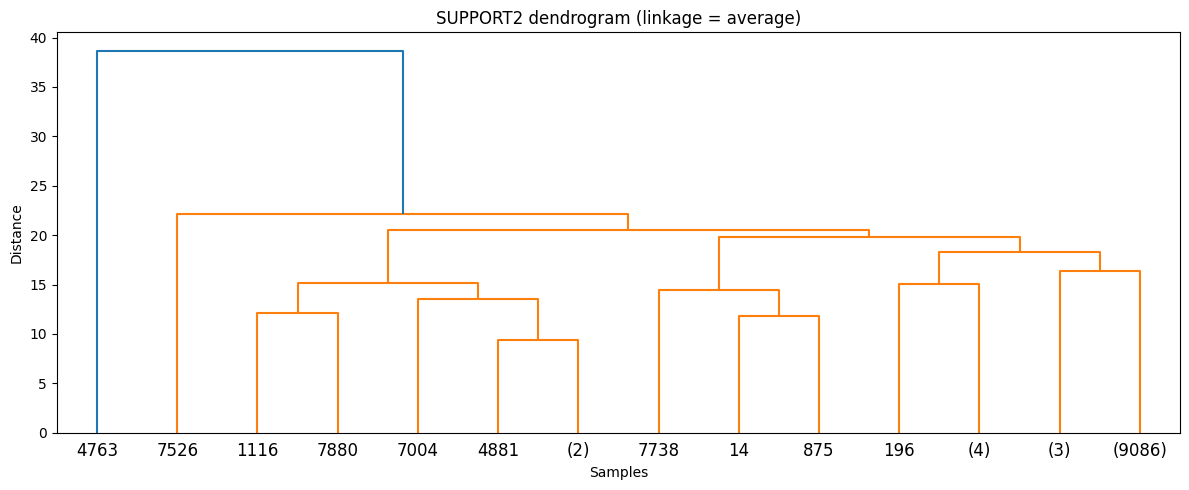

In [48]:
#Dendrogram for SUPPORT2 HAC

from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

#Use the best linkage method from tuning (average)
Z_s2 = linkage(X_scaled_s2, method=best_linkage_s2)

plt.figure(figsize=(12, 5))
dendrogram(Z_s2, truncate_mode='level', p=5)  # show only top few levels
plt.title(f"SUPPORT2 dendrogram (linkage = {best_linkage_s2})")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## Overall Clustering Summary

Across the three datasets, DBSCAN and HAC produced different clustering behavior depending on dataset size, feature structure, and parameter choices. DBSCAN was useful for identifying dense groups and noise points, while HAC provided linkage-based comparisons and dendrogram visualizations. The results show that clustering evaluation should consider both quantitative metrics, such as silhouette score, and practical cluster-size interpretation.
